# Lab 04-2 [ASSESSED] — Regression, Regularization, and the Bridge to Classification

**Course:** Applied Data Mining (DSAI 4102)

**Dataset:** California Housing (`fetch_california_housing`)

**Tools:** `pandas`, `scikit-learn`, `matplotlib`, `seaborn`

**Total marks:** 10

---

## What this lab covers

Lectures 04 and 05 look like two separate topics: classification, then regression.
They are not. **Logistic regression is a regression-shaped model doing a
classification job**, and the same dataset can usually be framed either way. This
lab makes you do exactly that: you will predict California house values as a
**number**, then reframe the same problem as a **category** and predict it again.

| Part | Tasks | Focus |
|---|---|---|
| **A** | 1–4 | Linear regression and its evaluation metrics |
| **B** | 5 | Optimization: closed form vs gradient descent, and why scaling matters |
| **C** | 6 | Regularization: Ridge and Lasso |
| **D** | 7–8 | The same problem as classification: logistic regression |
| **E** | 9 | Synthesis: choosing between the two framings |


## Marking

**This lab is assessed and worth 10 marks**, split evenly between working code and
written reasoning.

| Component | Marks |
|---|---|
| **Code** (Tasks 1–8) | **5.0** |
| Tasks 1–3: load, split, distribution check | 0.5 |
| Task 4: linear regression and metrics | 1.0 |
| Task 5: SGD, scaling comparison | 1.0 |
| Task 6: Ridge and Lasso | 1.0 |
| Tasks 7–8: logistic regression and evaluation | 1.5 |
| **Written reflections** (R1–R5) | **5.0** |
| R1 — interpreting regression metrics (Task 4) | 0.75 |
| R2 — scaling and gradient descent (Task 5) | 0.75 |
| R3 — regularization behaviour (Task 6) | 1.0 |
| R4 — classification vs regression metrics (Task 8) | 1.25 |
| R5 — synthesis (Task 9) | 1.25 |

### How the reflections are marked

Reflections carry the same weight as the code, and they are marked on **evidence
and reasoning, not length**. A reflection earns full marks when it:

- **Quotes your own numbers.** "My test R² was 0.58" scores; "the model performed well" does not.
- **Explains a mechanism**, not just an outcome. *Why* did that happen?
- **Answers the question that was asked**, including the parts that ask for a judgement call.

A generic, fluent paragraph that could have been written without running the
notebook scores zero, even if every sentence in it is true. Your `random_state` is
your own student ID, so **your numbers are specific to you** — a reflection whose
figures do not match your own output will be treated as not your work.

## Submission Guidelines

- **Deadline:** end of the lab session. Submissions are accepted only from students who attended.
- **Submission method:** upload to the D2L dropbox under the correct lab name.
- **File format:** convert your completed notebook to **PDF** and upload the PDF only. You may use [Vertopal](https://www.vertopal.com/en/convert/ipynb-to-pdf).
- **Before converting**, run the whole notebook top to bottom so that every output and figure is visible in the PDF. A PDF with empty cells cannot be marked.
- If you cannot finish during the session, ask your instructor about an extension **before** you leave.


## Setup

In [1]:
# Install required libraries (safe to re-run)
!pip install pandas numpy matplotlib scikit-learn seaborn --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import (LinearRegression, SGDRegressor,
                                  Ridge, Lasso, LogisticRegression)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn import metrics

# ---------------------------------------------------------------
# IMPORTANT: put the last two digits of YOUR student ID here.
# Your marks depend on your reflections matching YOUR numbers.
# ---------------------------------------------------------------
student_id_last2 = 42        # <-- CHANGE THIS, MY id is 60304642

print(f"Using random_state = {student_id_last2}")

Using random_state = 42


---

# Part A — Linear Regression

Lecture 05 focused on logistic regression. Linear regression is the model you met
in DSAI 3201, and the two are close relatives: both compute a weighted sum of the
features, **w·x + b**. The only difference is what happens to that sum afterwards.
Linear regression reports it directly as the prediction. Logistic regression pushes
it through a sigmoid to turn it into a probability. You will use both in this lab.

## Task 1 — Load and Inspect *(5 min)*

**Instructions**

1. Load the dataset with `fetch_california_housing(as_frame=True)` and take `.frame` as your DataFrame.
2. Print the shape and the column names.
3. Show the first 5 rows and `.describe()`.
4. State which column is the target. (*Hint: it is the one describing house value.*)

**No reflection for this task.**

In [8]:
# Add your code here

housing = fetch_california_housing(as_frame=True)
df = housing.frame
print("Shape:",df.shape, "\nColumns:", df.columns)

Shape: (20640, 9) 
Columns: Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


In [5]:
display(df.head())
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
# finding target according to the documentation of the housing dataset:
housing.target

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

*The target is MedHousVal, which stands for median house value for each district (plus other attributes) expressed in hundreds of thousands of dollars (x100000)*

## Task 2 — Train/Test Split *(5 min)*

**Instructions**

1. Separate `X` (all eight features) and `y` (`MedHouseVal`).
2. Split 80/20 with `random_state=student_id_last2`.
3. Print train and test sizes and confirm the ratio.

**No reflection for this task.**

In [10]:
# Add your code here
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=student_id_last2)

print(f"Train shape: {train_X.shape}, Test shape: {test_X.shape}")



Train shape: (16512, 8), Test shape: (4128, 8)


*Write your answer here.*

## Task 3 — Distribution Check *(10 min)*

**Instructions**

1. Plot the distribution of `MedHouseVal` for the full dataset, train, and test on one figure.
2. Print the mean and standard deviation of the target in each set.
3. Print `X_train.describe()` and look at the **ranges of the different features**. Note which feature has the largest spread and which has the smallest — you will need this in Task 5.

**No reflection for this task**, but do not skip step 3. Task 5 depends on it.

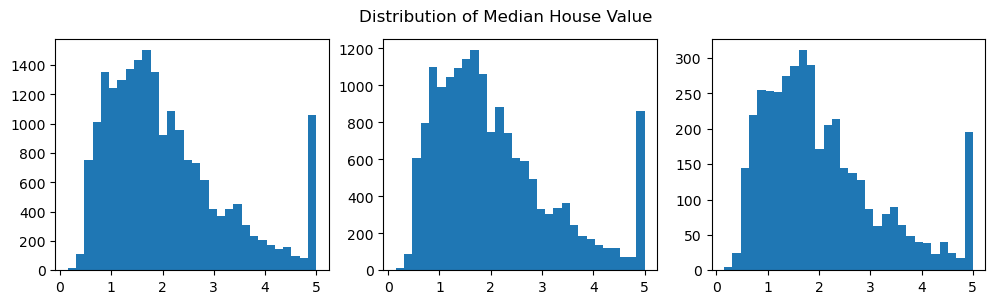

In [43]:
# Add your code here

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_size_inches(12, 3)
fig.suptitle('Distribution of Median House Value')
ax1.hist(y, bins=30)
ax2.hist(train_y, bins=30)
ax3.hist(test_y, bins=30)
plt.show()


In [47]:
print("Mean of the target in each set:")
print("Original: ", y.mean().round(2))
print("train split:",train_y.mean().round(2))
print("test split:", test_y.mean().round(2))

Mean of the target in each set:
Original:  2.07
train split: 2.07
test split: 2.06


In [53]:
train_X.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.582290
std,1.904294,12.602499,2.387375,0.433215,1137.056380,11.578744,2.136665,2.005654
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000
25%,2.566700,18.000000,4.452055,1.006508,789.000000,2.428799,33.930000,-121.810000
50%,3.545800,29.000000,5.235874,1.049286,1167.000000,2.817240,34.260000,-118.510000
75%,4.773175,37.000000,6.061037,1.100348,1726.000000,3.280000,37.720000,-118.010000
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000


*Just by looking at the numbers, Population and HouseAge has the highest std while considering mins and maxes*

## Task 4 — Linear Regression and Its Metrics *(15 min)* — **1.0 mark**

**Instructions**

1. Fit a `LinearRegression` on the training set.
2. Compute **MSE, RMSE, MAE, and R²** on both train and test. Present them in a small table.
3. Plot predicted vs actual values on the test set, with a 45-degree reference line.
4. Print the fitted coefficients alongside their feature names.

---

### Reflection R1 *(0.75 marks)*

Answer all three parts, quoting your own numbers.

**(a)** Your target is measured in units of $100,000. Convert your **test MAE** into
dollars and write the sentence you would say to a homeowner: "on average this model
is off by about $____".

**(b)** Your RMSE is larger than your MAE. Explain what that gap tells you about the
errors this model makes. (*It is a property of how the two are calculated.*)

**(c)** Your test R² is some value between 0 and 1. A colleague says "R² of 0.6 means
the model is 60% accurate." Explain why that statement is wrong, and say what R²
actually measures.

Model Performance on the train split:


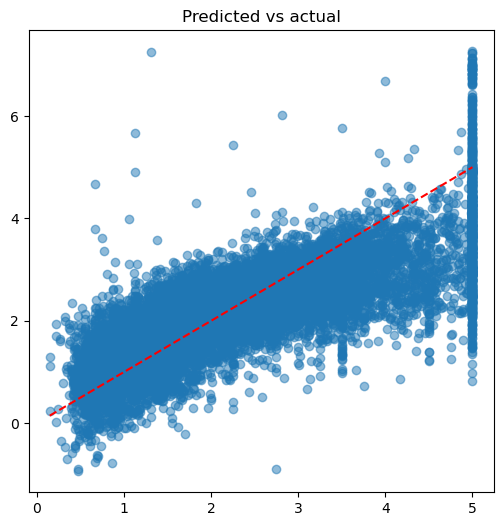

Mean Absolute Error:  0.53
Mean Squared Error:  0.52
RMSE:  0.72
r2 score: 0.61

Model Performance on the test split
--- Model Coefficients ---
MedInc: 0.4487
HouseAge: 0.0097
AveRooms: -0.1233
AveBedrms: 0.7831
Population: -0.0000
AveOccup: -0.0035
Latitude: -0.4198
Longitude: -0.4337
Intercept: -37.0233
--------------------------


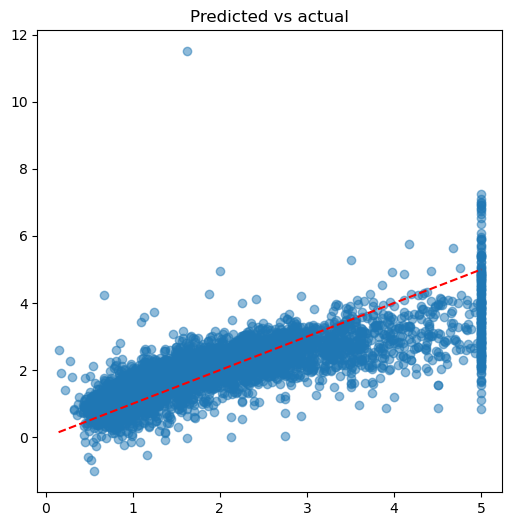

Mean Absolute Error:  0.53
Mean Squared Error:  0.56
RMSE:  0.75
r2 score: 0.58




In [77]:
# Add your code here
model = LinearRegression().fit(train_X, train_y)
y_pred = model.predict(test_X)
y_train_pred = model.predict(train_X)
print("Model Performance on the train split:")
splits = [train_X, train_y, test_X, test_y]
titleX = "Train"
for i in range(0,4,2):
    
    y_pred = y_pred = model.predict(splits[i])
    mae_score = metrics.mean_absolute_error(splits[i+1], y_pred)
    mse_score = metrics.mean_squared_error(splits[i+1],y_pred)
    rmse_score = mse_score**(1/2)
    r2 = metrics.r2_score(splits[i+1], y_pred)
    if i ==2:
        print("Model Performance on the test split")
        print("--- Model Coefficients ---")
        # Use zip to pair feature names with their learned weight coefficients
        for feature, coef in zip(train_X.columns, model.coef_):
            print(f"{feature}: {coef:.4f}")
        print(f"Intercept: {model.intercept_:.4f}")
        print("-" * 26)
    plt.figure(figsize=(6,6))
    plt.scatter(splits[i+1], y_pred, alpha=0.5)
    plt.plot([min(splits[i+1]), max(splits[i+1])], [min(splits[i+1]), max(splits[i+1])], color='red', linestyle='--', label='Ideal: y = x')
    plt.title(f"Predicted vs actual")
    plt.show()

    print("Mean Absolute Error: ", mae_score.round(2))
    print("Mean Squared Error: ", mse_score.round(2))
    print("RMSE: ", rmse_score.round(2))
    print("r2 score:", round(r2, 2))
    print()

print()
    

**test MAE interpretation:** This Linear Regression model can predict house price in california within error range of 53000$. 

**test RMSE interpretation:** While the model's expected error range of price prediction is 53000$, higher rmse means there are some houses whose price will be mispredicted by big margins.

**test R2 interpretation:** Accuracy is for classification tasks, where the prediction is either correct or not correct. In regression, we are predicting continous values, so models do not predict the exact continuous target value. R2 score represent the ability of the model to explain the variance of the target using the features.

---

# Part B — How the Model Is Actually Fitted

`LinearRegression` solves for the coefficients in one step using the **normal
equation** — a closed-form matrix formula. `SGDRegressor` finds the same
coefficients by **gradient descent**, taking many small steps downhill, which is
the algorithm you saw derived for logistic regression in Lecture 05 (slides 22–23).

They should reach the same answer. Watch what happens when they do not.

## Task 5 — Gradient Descent and Why Scaling Matters *(20 min)* — **1.0 mark**

**Instructions**

1. Fit an `SGDRegressor(loss="squared_error", max_iter=1000, random_state=student_id_last2)` on the **unscaled** training data. Compute its test MSE.
2. Now build a pipeline: `make_pipeline(StandardScaler(), SGDRegressor(...))` with the same settings. Fit it and compute its test MSE.
3. Build a table comparing all three: `LinearRegression`, unscaled SGD, scaled SGD.
4. Plot the three test MSE values as a bar chart. You will probably need a **log scale** on the y-axis to see them all.

> If the unscaled SGD produces a huge number, `inf`, or `nan`, that is not a bug.
> That **is** the result. Report it and explain it.

---

### Reflection R2 *(0.75 marks)*

**(a)** Report your three test MSE values. How many times larger is the unscaled SGD
error than the scaled one?

**(b)** Using the feature ranges you printed in Task 3, explain **mechanically** why
gradient descent struggles on unscaled data. Your answer should refer to the
step size and to at least two specific features by name.

**(c)** `LinearRegression` needed no scaling at all and got a good answer in one step.
So why does anyone use gradient descent? Give one concrete situation where the
closed-form solution is not an option.

--- Model Comparison ---
                Model     Test MSE
    Linear Regression 5.600000e-01
       SGD (Unscaled) 3.232574e+28
SGD (Standard Scaled) 5.505988e-01
------------------------


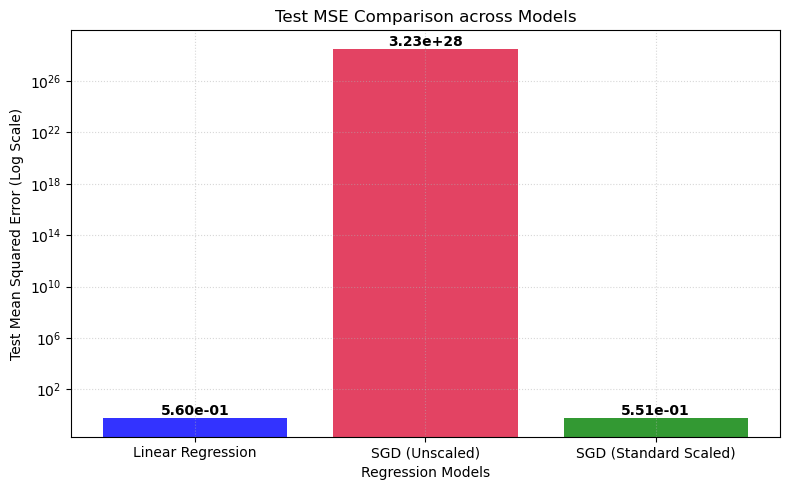

In [78]:

sgd_unscaled = SGDRegressor(loss="squared_error", max_iter=1000, random_state=student_id_last2)
sgd_unscaled.fit(train_X, train_y)
y_pred_unscaled = sgd_unscaled.predict(test_X)
mse_unscaled = metrics.mean_squared_error(test_y, y_pred_unscaled)

# 2. Scaled SGD Regressor Pipeline
sgd_scaled_pipe = make_pipeline(StandardScaler(), SGDRegressor(loss="squared_error", max_iter=1000, random_state=student_id_last2))
sgd_scaled_pipe.fit(train_X, train_y)
y_pred_scaled = sgd_scaled_pipe.predict(test_X)
mse_scaled = metrics.mean_squared_error(test_y, y_pred_scaled)

# 3. Comparison Table

mse_linear_reg = 0.56 

df_compare = pd.DataFrame({
    "Model": ["Linear Regression", "SGD (Unscaled)", "SGD (Standard Scaled)"],
    "Test MSE": [mse_linear_reg, mse_unscaled, mse_scaled]
})
print("--- Model Comparison ---")
print(df_compare.to_string(index=False))
print("-" * 24)

# 4. Plot Test MSE Values as a Bar Chart (Log Scale)
plt.figure(figsize=(8, 5))
models = df_compare["Model"]
mse_values = df_compare["Test MSE"]

plt.bar(models, mse_values, color=['blue', 'crimson', 'green'], alpha=0.8)
plt.yscale('log') # Log scale handles the massive unscaled value

plt.xlabel('Regression Models')
plt.ylabel('Test Mean Squared Error (Log Scale)')
plt.title('Test MSE Comparison across Models')
plt.grid(True, which="both", linestyle=':', alpha=0.5)

# Annotate values on top of bars safely (handles inf/nan strings gracefully)
for i, v in enumerate(mse_values):
    plt.text(i, v, f"{v:.2e}" if v < float('inf') else "inf", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


**a:** Scaled SGD performed slightly better than Linear Regression but SGD performed way worse according to MSE, this is all because of the difference in range of values for different features.

**b:** A single value of learning rate is shared across all features. for a feature like "Population", the range is (3,3500+), while for houseAge range is (3, 15). This massive difference in ranges will cause issues. A step size (learning rate) small enough to properly change HouseAge coefficiants will be too large Population coefficiants, leading to extreme over-correction.

**c:** Scaled SGD uses gradient decent and is highly efficient for high dimentional data (big number of features like 100000) becaause it uses basic matrix multiplication using numpy which is extremeely efficient. Linear regression for large features will hang, because there won't be enough memory.

---

# Part C — Regularization

Lecture 05 slides 57–60 covered overfitting and the two standard penalties. Ridge
(L2) shrinks coefficients toward zero; Lasso (L1) can push them **exactly** to zero,
which makes it a feature selector as well as a regularizer.

## Task 6 — Ridge and Lasso *(20 min)* — **1.0 mark**

**Instructions**

1. Fit `Ridge(alpha=1.0)` and `Lasso(alpha=0.1)` on the **scaled** training data (use `make_pipeline` for both, so the penalty applies to comparable coefficients).
2. Compare test MSE and R² against plain `LinearRegression` in a table.
3. Plot the coefficient magnitudes for all three models on one grouped bar chart.
4. Print **how many coefficients Lasso set exactly to zero**, and name them.
5. Refit Lasso for `alpha` in `[0.001, 0.01, 0.1, 1.0]` and plot the number of surviving non-zero coefficients against alpha.

---

### Reflection R3 *(1.0 mark)*

**(a)** Report the test MSE of all three models. Did regularization *improve* test
performance here? Given the shape of this dataset (how many rows, how many
features), explain whether you would have expected it to.

**(b)** Which coefficients did your Lasso zero out at `alpha=0.1`? Look at what those
features represent. Is dropping them defensible, or has Lasso discarded something
you would have kept?

**(c)** From your alpha sweep: describe what happens to the number of surviving
features as alpha increases, and explain why L1 can zero a coefficient exactly
while L2 only shrinks it.

In [105]:
# Add your code here
ridge_pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
lasso_pipe = make_pipeline(StandardScaler(), Lasso(alpha=0.1))

ridge_pipe.fit(train_X, train_y)
lasso_pipe.fit(train_X, train_y)

y_pred_lr = model.predict(test_X)
y_pred_ridge = ridge_pipe.predict(test_X)
y_pred_lasso = lasso_pipe.predict(test_X)

mse_lr = metrics.mean_squared_error(test_y, y_pred_lr)
r2_lr = metrics.r2_score(test_y, y_pred_lr)

mse_ridge = metrics.mean_squared_error(test_y, y_pred_ridge)
r2_ridge = metrics.r2_score(test_y, y_pred_ridge)

mse_lasso = metrics.mean_squared_error(test_y, y_pred_lasso)
r2_lasso = metrics.r2_score(test_y, y_pred_lasso)

df_compare = pd.DataFrame({
    "Model": ["LinearRegression", "Ridge (alpha=1.0)", "Lasso (alpha=0.1)"],
    "Test MSE": [mse_lr, mse_ridge, mse_lasso],
    "Test R²": [r2_lr, r2_ridge, r2_lasso]
})
print("RegularizationPerformance Summary ")
display(df_compare)
print("----------------------------------------------", "\n")


RegularizationPerformance Summary 


,Model,Test MSE,Test R²
0,LinearRegression,0.555892,0.575788
1,Ridge (alpha=1.0),0.555855,0.575816
2,Lasso (alpha=0.1),0.679629,0.481361


---------------------------------------------- 



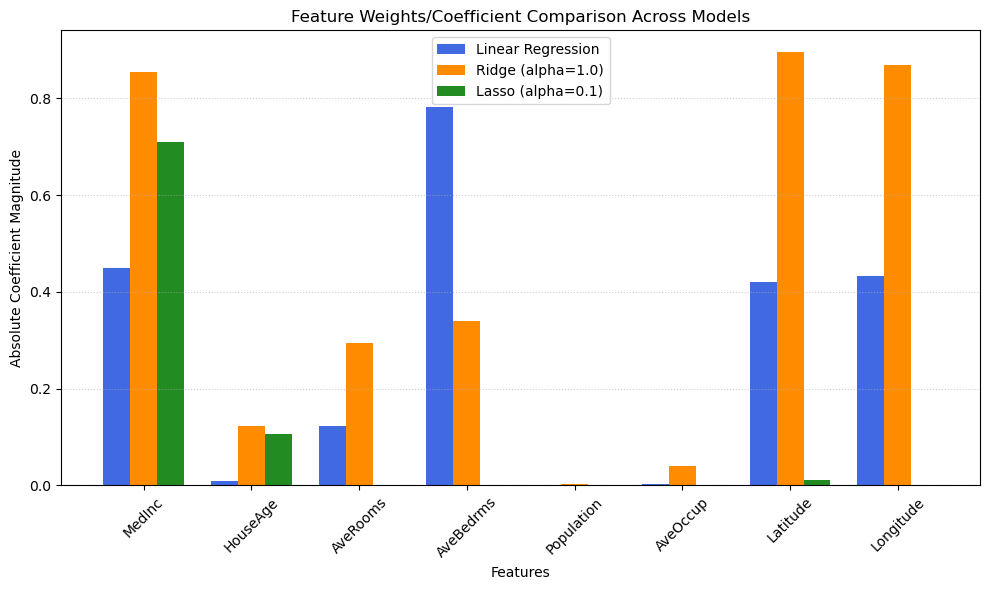

In [85]:
# 3. Plot Coefficient Magnitudes on a Grouped Bar Chart
features = train_X.columns
coef_lr = model.coef_
coef_ridge = ridge_pipe.named_steps['ridge'].coef_
coef_lasso = lasso_pipe.named_steps['lasso'].coef_

x = np.arange(len(features))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, np.abs(coef_lr), width, label='Linear Regression', color='royalblue')
plt.bar(x, np.abs(coef_ridge), width, label='Ridge (alpha=1.0)', color='darkorange')
plt.bar(x + width, np.abs(coef_lasso), width, label='Lasso (alpha=0.1)', color='forestgreen')

plt.xlabel('Features')
plt.ylabel('Absolute Coefficient Magnitude')
plt.title('Feature Weights/Coefficient Comparison Across Models')
plt.xticks(x, features, rotation=45)
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [86]:
# Names of features whose coefficiant got to zero in Lasso model:
zero_indices = np.where(coef_lasso == 0)[0]
zero_features = features[zero_indices].tolist()
print(f"Lasso (alpha=0.1) set exactly {len(zero_features)} coefficients to zero.")
print(f"Zeroed features: {zero_features}\n")

Lasso (alpha=0.1) set exactly 5 coefficients to zero.
Zeroed features: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']



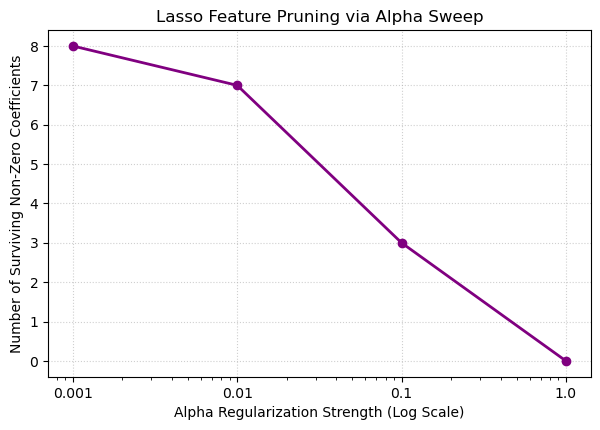

In [90]:
# Lasso using different regularization strength
alphas = [0.001, 0.01, 0.1, 1.0]
surviving_counts = []

for a in alphas:
    l_pipe = make_pipeline(StandardScaler(), Lasso(alpha=a))
    l_pipe.fit(train_X, train_y)
    c = l_pipe.named_steps['lasso'].coef_
    non_zero_count = np.sum(c != 0)
    surviving_counts.append(non_zero_count)
plt.figure(figsize=(7, 4.5))
plt.plot(alphas, surviving_counts, marker='o', color='purple', linewidth=2)
plt.xscale('log')
plt.xlabel('Alpha Regularization Strength (Log Scale)')
plt.ylabel('Number of Surviving Non-Zero Coefficients')
plt.title('Lasso Feature Pruning via Alpha Sweep')
plt.xticks(alphas, labels=[str(a) for a in alphas])
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**(a)**  Regularization did not improve the performance whatsoever, infact Lasso performed a bit worse than the Linear regression. This is expected because the dataset has low ratio of features and records (low dimentionality). These regularization techniques are helpful for reducing overfitting in high dimentional datasets.

**(b)**  at alpha =0.1, lasso dropped 5 out of 8 features. Those dropped features include very important information for the model. Dropping something like number of rooms/bedrooms and district population are important features for determining the price of a house.

**(c)** As alpha increases in Lasso, the number of features gets reduced because their coefficiants are shrinked to zero. Lasso usees absolute value penality on the coefficients, that can result in zero. but Ridge uses squared penalty, which then is constrained to not ever put coefficient to zero.

---

# Part D — The Same Problem as Classification

Everything so far predicted a **number**. Now predict a **category** from the same
data: is this district *expensive* or not?

This is the bridge between the two lectures. Logistic regression computes the same
weighted sum **w·x + b** that linear regression does, then squashes it through a
sigmoid into a probability, and thresholds it at 0.5. The model is nearly
identical. What changes completely is **how you are allowed to evaluate it** — and
that is the point of this part.

## Task 7 — Reframe as Classification *(15 min)* — part of the 1.5 code marks

**Instructions**

1. Create a binary target: `y_class = (y > y.median()).astype(int)`. A district is "expensive" (1) if its median house value is above the dataset median.
2. Split with the **same** `random_state=student_id_last2` so the rows match your regression split.
3. Print the class balance in train and test. Is this dataset balanced or imbalanced?
4. Fit `LogisticRegression` inside a `StandardScaler` pipeline (`max_iter=1000`).
5. Print train and test **accuracy**.

**No separate reflection** — Task 8 covers both.

In [107]:
# Creating the Y class
y_class = (y > y.median()).astype(int)

train_X, test_X, train_y_class, test_y_class = train_test_split(
    X, y_class, test_size=0.2, random_state=student_id_last2
)

print("--- Class Balance Check ---")
print("Train set split counts:\n", train_y_class.value_counts(normalize=True).round(4))
print("\nTest set split counts:\n", test_y_class.value_counts(normalize=True).round(4))
print("-" * 27)

# 4. Fit LogisticRegression inside a StandardScaler pipeline
log_reg_pipe = make_pipeline(
    StandardScaler(), 
    LogisticRegression(max_iter=1000, random_state=student_id_last2)
)
log_reg_pipe.fit(train_X, train_y_class)

train_acc = log_reg_pipe.score(train_X, train_y_class)
test_acc = log_reg_pipe.score(test_X, test_y_class)

print("--- Model Accuracy Metrics ---")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print("-" * 30)

--- Class Balance Check ---
Train set split counts:
 MedHouseVal
1    0.5006
0    0.4994
Name: proportion, dtype: float64

Test set split counts:
 MedHouseVal
0    0.5031
1    0.4969
Name: proportion, dtype: float64
---------------------------
--- Model Accuracy Metrics ---
Training Accuracy: 0.8289
Testing Accuracy:  0.8261
------------------------------


**Reflection: For classification task, our model correcly classifies whether a house is priced above or below median by 82% accuracy**

## Task 8 — Evaluating the Classifier *(20 min)* — part of the 1.5 code marks

Now apply the Lecture 04 evaluation toolkit to this model.

**Instructions**

1. Plot the confusion matrix on the test set with `sns.heatmap()`.
2. Print accuracy, precision, recall, and F1.
3. Train a `DummyClassifier(strategy="most_frequent")` and print its accuracy for comparison.
4. **Convert your regression model into a classifier.** Take your Task 4 `LinearRegression` predictions on the test set and threshold them at the same median: `pred_class = (y_pred_lin > threshold).astype(int)`. Compute its accuracy, precision, recall, and F1.
5. Put logistic regression, the thresholded linear regression, and the dummy in one comparison table.

---

### Reflection R4 *(1.25 marks)*

**(a)** Report the dummy's accuracy. Compare it to the dummy in **Lab 04 Task 9**,
which reached roughly 76% on the Adult data. Why is the baseline so much weaker
here? Refer to the class balance you printed in Task 7.

**(b)** Your thresholded linear regression and your logistic regression both do
classification. Report both sets of numbers. Which wins, and by how much? Was the
margin larger or smaller than you expected?

**(c)** You now have two models of the same data: one predicting a number, one
predicting a category. **What information did you destroy when you thresholded at
the median?** Give a concrete example of a district where that loss matters.

**(d)** You cannot compute R² for the logistic model, and you cannot compute an F1
score for the linear one without thresholding it first. Explain why the two
families of metrics are not interchangeable.

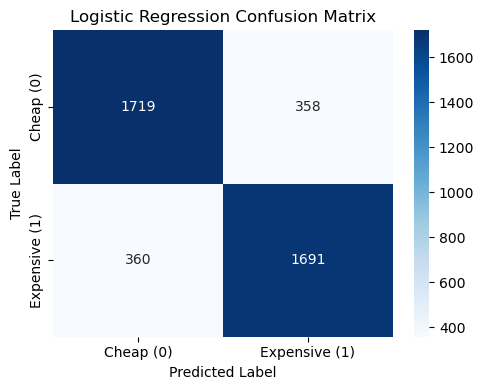

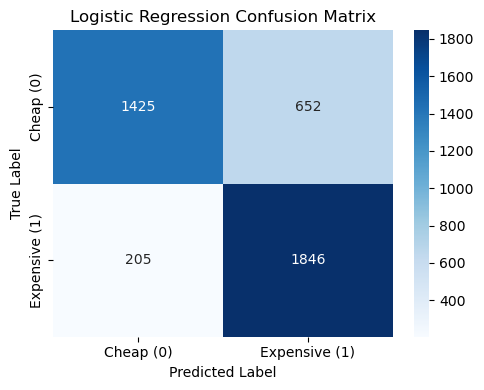

--- Classification Evaluation Summary ---
             Classifier Model  Accuracy  Precision  Recall  F1 Score
          Logistic Regression    0.8261     0.8253  0.8245    0.8249
Thresholded Linear Regression    0.7924     0.7390  0.9000    0.8116
             Dummy Classifier    0.4969     0.4969  1.0000    0.6639
------------------------------------------


In [ ]:


# Define the threshold using the original dataset median
threshold = y.median()

# 1. Plot the Confusion Matrix for Logistic Regression

y_pred_log = log_reg_pipe.predict(test_X)
cm_log = metrics.confusion_matrix(test_y_class, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cheap (0)', 'Expensive (1)'],
            yticklabels=['Cheap (0)', 'Expensive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

# 2. Get metrics for Logistic Regression
acc_log = metrics.accuracy_score(test_y_class, y_pred_log)
prec_log = metrics.precision_score(test_y_class, y_pred_log)
rec_log = metrics.recall_score(test_y_class, y_pred_log)
f1_log = metrics.f1_score(test_y_class, y_pred_log)

# 3. Train Dummy Classifier
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(train_X, train_y_class)
y_pred_dummy = dummy.predict(test_X)
acc_dummy = metrics.accuracy_score(test_y_class, y_pred_dummy)
prec_dummy = metrics.precision_score(test_y_class, y_pred_dummy, zero_division=0)
rec_dummy = metrics.recall_score(test_y_class, y_pred_dummy, zero_division=0)
f1_dummy = metrics.f1_score(test_y_class, y_pred_dummy, zero_division=0)

# 4. Threshold the Linear Regression predictions from Task 4

y_pred_lin_class = (y_pred_lr > threshold).astype(int)
cm_log = metrics.confusion_matrix(test_y_class, y_pred_lin_class)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cheap (0)', 'Expensive (1)'],
            yticklabels=['Cheap (0)', 'Expensive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix, for thresholded one')
plt.tight_layout()
plt.show()

acc_lin = metrics.accuracy_score(test_y_class, y_pred_lin_class)
prec_lin = metrics.precision_score(test_y_class, y_pred_lin_class)
rec_lin = metrics.recall_score(test_y_class, y_pred_lin_class)
f1_lin = metrics.f1_score(test_y_class, y_pred_lin_class)

# 5. Master Comparison Table
df_class_compare = pd.DataFrame({
    "Classifier Model": ["Logistic Regression", "Thresholded Linear Regression", "Dummy Classifier"],
    "Accuracy": [acc_log, acc_lin, acc_dummy],
    "Precision": [prec_log, prec_lin, prec_dummy],
    "Recall": [rec_log, rec_lin, rec_dummy],
    "F1 Score": [f1_log, f1_lin, f1_dummy]
}).round(4)

print("--- Classification Evaluation Summary ---")
print(df_class_compare.to_string(index=False))
print("-" * 42)



***I don't know what Adult Data is in the reflection question, likely a mix up with different dataset***
**(a)** 
Dummy's accuracy is close the 50/50 chance, which is because we created y_class on median. the Y-class is balanced with equal 0s and 1 (almost), dummy tries to predict most frequent and is correct 50% of the time because of the equal distribution.

**(b)** Linear regression wins when considering raw accuracy numbers. Better than dummy and slightly better than thresholded LR. But when considering the Confusion matrix, Thresholded one misclassifies cheap houses as expensive way often. This reduces the chance of classifying an expensive house as cheap, which could be bad accordding to different situations.

**(c)** When predicting the exact price of the house, that requires explaining what each error means. That can be useful. Classifiying whether a house is above or bellow median is different business decision, and we are destroying a lot of info wether the extent of price.

**(d)** r2 and mse require continuous residual errors. they measure distance between the actual vs predicted. Calculating these on output of Logistic regression will produce nonsense values since Logistic regression's output is discrete values.  Similarly f1,precision,recall don't make sense for continouse target prediction since the model can never predict exact True Continues values

---

# Part E — Synthesis

The final reflection carries more weight than any single piece of code in this lab.
Take your time with it.

## Task 9 — Choosing a Framing *(15 min)* — reflection only

There is no code to write for this task. Read back over your own outputs from
Tasks 4, 6, and 8 before you answer.

---

### Reflection R5 *(1.25 marks)*

A city housing authority approaches you with the California dataset. They want to
identify districts where housing is unaffordable so they can direct a subsidy
programme.

**(a)** You could hand them your regression model (a predicted dollar value per
district) or your classifier (expensive / not expensive). **Recommend one**, and
justify it by reference to what the authority actually needs to do with the output.
There is no single correct answer, but there is a correct *kind* of argument.

**Answer:** The classification model will not be sufficient for the housing authority, since that model will put multi-million dollar houses and slightly expensive house in the same category, giving the authority less info. The authority needs to work with proper numbers, So they can subsidy dynamically according to the unaffordability of the houses in the given district.

**(b)** The authority says: "We would rather wrongly flag a district as unaffordable
than miss one that really is." Translate that sentence into the language of Lecture
04: which metric are they asking you to prioritise, and which are they willing to
sacrifice? Would you keep the 0.5 threshold, or move it? Which way?

**Answer:** The metric they are trying to prioritize is recall, they want to minimize fall negatives which means missing districts that need their service. By moving the threshold down, we can improve/increase recall which will help catch most unaffordable housing districts.

**(c)** Using your own numbers from this lab, state **one specific limitation** of
whichever model you recommended, and one thing you would do next to address it.

**answer:** R2 score:0.58 of Linear regression was underwhelming, because it means that 0.42 of the housing in california cannot be explained by our model. Furthermore, large RMSE compared to mae means the model is being affected by outliers massively. which could cause issues for the housing aurthority in their subsidy calculation in districts with outliers. Improving this could be tried by: including location of the houses since some houses cost more due to their nearedness to major economic hubs (malls, coasts, others). And also dealing with outliers in a way to eliminate the most expensive houses, since they are the ones affecting our RMSE so much.

**(d)** In one or two sentences: this lab used one dataset and framed it two
different ways. What determined which framing was appropriate — something about the
*data*, or something about the *question being asked*?

**Answer:** Determining which frame is appropriate entirely depends on the "question being asked". This task proves that we can adapt our setup depending on the what is being asked, what we are looking for, what are we trying to predict. The data is the tool used for the questions, we need to adapt it be able to answer whatever question is being asked, which could include changing the framing from regression to classification.

In [ ]:
# Add your code here


*Write your answer here.*

---

## Before you submit

- [ ] `student_id_last2` is set to **your** student ID digits, not 42.
- [ ] The notebook runs top to bottom without errors (Runtime → Restart and run all).
- [ ] Every figure is visible in the output.
- [ ] All five reflections (R1–R5) are answered, and **each one quotes your own numbers**.
- [ ] Exported to PDF, and the PDF shows your outputs.

**A reminder on the reflections.** They are half the marks. A fluent paragraph that
would read the same regardless of what your notebook printed will score zero. Your
seed is your own, so your numbers are your own — use them.
